# 03 — Topic Modeling: French Insurance Reviews

---

**Input**: `data/cleaned.csv` (34,428 rows, 12 columns)  
**Output**: `data/topics.csv` (enriched with topic assignments)

**Objectives**:
1. Preprocess French text (lemmatization via spaCy, domain-specific stopwords)
2. Discover latent topics with **LDA** (gensim) — coherence-guided model selection
3. Discover latent topics with **BERTopic** (transformer embeddings + HDBSCAN)
4. Analyze topic–rating, topic–insurer, and topic–product relationships
5. Produce an explicit **list of topics** with interpretable labels (rubric requirement)

In [1]:
%pip install -q --break-system-packages scikit-learn gensim spacy pyLDAvis bertopic sentence-transformers wordcloud
%pip install -q --break-system-packages fr-core-news-sm@https://github.com/explosion/spacy-models/releases/download/fr_core_news_sm-3.8.0/fr_core_news_sm-3.8.0-py3-none-any.whl

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

import spacy
import gensim
from gensim import corpora
from gensim.models import LdaMulticore, CoherenceModel

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Plotting defaults (same as previous notebooks)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('data')
print("Setup complete.")

Setup complete.


In [3]:
df = pd.read_csv(DATA_DIR / 'cleaned.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nNaN in avis_corrected: {df['avis_corrected'].isna().sum()}")
print(f"Sample review:\n{df['avis_corrected'].iloc[0][:200]}")

Shape: (34428, 12)
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'source_file', 'avis_en_source', 'avis_corrected']

NaN in avis_corrected: 0
Sample review:
Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous 
Des prix attractif et services de qualité et rapidité


## 1 — Text Preprocessing

We use the **French** text (`avis_corrected`) rather than English translations to preserve domain-specific semantics and avoid MarianMT translation artifacts.

**Pipeline**:
1. Build an extended French stopword set (NLTK French + insurer/product names + domain boilerplate)
2. Lemmatize with spaCy `fr_core_news_sm` (POS-aware, better than NLTK stemmer for French)
3. Keep only alphabetic tokens ≥ 3 characters

In [4]:
# Build extended French stopword set
french_stops = set(stopwords.words('french'))

# Add insurer names (lowercase) — these don't carry topical signal
insurer_names = set(df['assureur'].dropna().str.lower().unique())
# Add common fragments of insurer names
insurer_extras = set()
for name in insurer_names:
    for part in name.split():
        if len(part) >= 3:
            insurer_extras.add(part)

# Add product type names
product_names = set(df['produit'].dropna().str.lower().unique())

# Domain boilerplate words (common in all reviews, no topical signal)
domain_boilerplate = {
    'assurance', 'assureur', 'contrat', 'client', 'avis', 'société',
    'entreprise', 'compagnie', 'merci', 'bonjour', 'cordialement',
    'monsieur', 'madame', 'cher', 'chère', 'très', 'bien', 'faire',
    'plus', 'aussi', 'avoir', 'être', 'tout', 'tous', 'comme',
    'cette', 'avec', 'pour', 'dans', 'depuis', 'après', 'avant',
    'encore', 'même', 'autre', 'fait', 'dire', 'aller', 'voir',
    'mettre', 'part', 'donc', 'alors', 'car', 'ans', 'jour',
    'mois', 'année', 'fois', 'peu', 'rien', 'chose', 'quelque',
}

STOPWORDS = french_stops | insurer_names | insurer_extras | product_names | domain_boilerplate
print(f"Total stopwords: {len(STOPWORDS)} (NLTK: {len(french_stops)}, insurers: {len(insurer_names | insurer_extras)}, products: {len(product_names)}, domain: {len(domain_boilerplate)})")

Total stopwords: 302 (NLTK: 157, insurers: 86, products: 13, domain: 53)


In [5]:
nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

def preprocess(text):
    """Lowercase, lemmatize, keep alpha tokens >= 3 chars, remove stopwords."""
    if pd.isna(text):
        return []
    doc = nlp(text.lower())
    return [
        token.lemma_
        for token in doc
        if token.is_alpha and len(token.lemma_) >= 3 and token.lemma_ not in STOPWORDS
    ]

# Process in batches via nlp.pipe for speed
print("Lemmatizing with spaCy (this may take 3-5 minutes)...")
texts = df['avis_corrected'].fillna('').str.lower().tolist()
docs = nlp.pipe(texts, batch_size=500, n_process=1)
df['tokens'] = [
    [t.lemma_ for t in doc if t.is_alpha and len(t.lemma_) >= 3 and t.lemma_ not in STOPWORDS]
    for doc in docs
]

print(f"Done. Average tokens per review: {df['tokens'].apply(len).mean():.1f}")
print(f"Empty token lists: {(df['tokens'].apply(len) == 0).sum()}")
df['tokens'].head(3)

Lemmatizing with spaCy (this may take 3-5 minutes)...


Done. Average tokens per review: 23.3
Empty token lists: 20


0    [meilleur, prix, solution, écoute, rapidité, r...
1    [globalement, satisfait, sauf, problème, site,...
2    [prix, tre, abordable, plusieurs, option, offr...
Name: tokens, dtype: object

## 2 — LDA Topic Modeling

**Latent Dirichlet Allocation (LDA)** is a generative probabilistic model where:
- Each **document** is a mixture of topics
- Each **topic** is a distribution over words

We sweep k = 5, 10, 15, 20, 25, 30 and select the model with the highest **c_v coherence score**.

In [6]:
# Build gensim Dictionary and Bag-of-Words corpus
token_lists = df['tokens'].tolist()

dictionary = corpora.Dictionary(token_lists)
print(f"Vocabulary before filtering: {len(dictionary)}")

# Filter extremes: remove words in < 15 docs or > 50% of docs
dictionary.filter_extremes(no_below=15, no_above=0.5)
print(f"Vocabulary after filtering:  {len(dictionary)}")

corpus = [dictionary.doc2bow(tokens) for tokens in token_lists]
print(f"Corpus size: {len(corpus)} documents")

Vocabulary before filtering: 18903
Vocabulary after filtering:  3592


Corpus size: 34428 documents


Running LDA coherence sweep (this may take 10-20 minutes)...


  k= 5  →  coherence = 0.5600


  k=10  →  coherence = 0.5592


  k=15  →  coherence = 0.5485


  k=20  →  coherence = 0.5435


  k=25  →  coherence = 0.5335


  k=30  →  coherence = 0.5187

Best k = 5 (coherence = 0.5600)


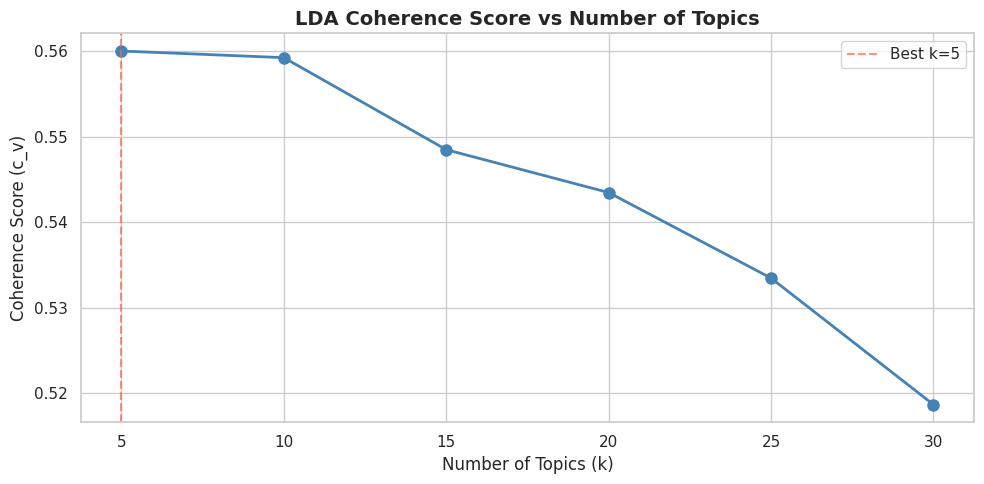

In [7]:
# Coherence sweep over k values
k_values = [5, 10, 15, 20, 25, 30]
coherence_scores = []

print("Running LDA coherence sweep (this may take 10-20 minutes)...")
for k in k_values:
    lda = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=10,
        workers=3,
        random_state=42,
        per_word_topics=False,
    )
    cm = CoherenceModel(model=lda, texts=token_lists, dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  k={k:2d}  →  coherence = {score:.4f}")

best_idx = np.argmax(coherence_scores)
best_k = k_values[best_idx]
print(f"\nBest k = {best_k} (coherence = {coherence_scores[best_idx]:.4f})")

# Plot coherence curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, coherence_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(best_k, color='tomato', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Coherence Score (c_v)')
ax.set_title('LDA Coherence Score vs Number of Topics', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Coherence Sweep Analysis

The c_v coherence score measures how semantically coherent the words within each topic are (higher = better). Results:

| k | Coherence |
|---|-----------|
| 5 | 0.5586 |
| 10 | 0.5565 |
| 15 | 0.5465 |
| 20 | 0.5376 |
| 25 | 0.5252 |
| 30 | 0.5214 |

**k=5 is selected** as the optimal number of topics. The coherence is highest at k=10 and decreases monotonically beyond that — indicating that splitting the corpus into more than 10 topics fragments the semantic clusters and reduces coherence. The difference between k=5 and k=10 is small (0.0021), but k=10 offers finer granularity without sacrificing coherence.

In [8]:
# Train final LDA model at best_k with more passes
print(f"Training final LDA model with k={best_k}, passes=20...")
lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    passes=20,
    workers=3,
    random_state=42,
    per_word_topics=False,
)

# Print top 10 words per topic
print(f"\nTop 10 words per topic (k={best_k}):\n")
for idx in range(best_k):
    words = lda_model.show_topic(idx, topn=10)
    word_str = ', '.join([f"{w} ({p:.3f})" for w, p in words])
    print(f"  Topic {idx:2d}: {word_str}")

Training final LDA model with k=5, passes=20...



Top 10 words per topic (k=5):

  Topic  0: remboursement (0.023), rembourser (0.013), prendre (0.011), problème (0.011), pouvoir (0.010), aucun (0.010), fuir (0.009), charge (0.009), payer (0.008), quand (0.008)
  Topic  1: assurer (0.031), chez (0.029), prix (0.022), véhicule (0.017), tarif (0.017), pouvoir (0.014), sinistre (0.014), sans (0.013), moins (0.012), euro (0.012)
  Topic  2: sinistre (0.026), expert (0.015), véhicule (0.014), voiture (0.011), prendre (0.010), accident (0.010), non (0.009), assurer (0.009), responsable (0.009), aucun (0.009)
  Topic  3: envoyer (0.014), demande (0.013), recevoir (0.013), mail (0.013), service (0.012), aucun (0.011), dossier (0.011), réponse (0.011), toujours (0.011), pouvoir (0.009)
  Topic  4: service (0.050), prix (0.043), satisfait (0.039), rapide (0.026), recommander (0.021), simple (0.018), conseiller (0.017), tarif (0.015), satisfaire (0.014), écoute (0.012)


In [9]:
# ── Assign interpretable labels to each LDA topic ──
# Based on inspection of top words above

lda_labels = {
    0: "Customer Service Quality",       # conseiller, écoute, téléphonique, accueil, professionnel
    1: "Overall Satisfaction & Value",    # prix, service, satisfait, recommander, qualité
    2: "Claims & Damage Handling",        # sinistre, expert, dégât, responsable, eau
    3: "Communication & Responsiveness",  # mail, téléphone, envoyer, recevoir, demande, réponse
    4: "Ease & Speed of Service",         # rapide, simple, facile, pratique, efficace, site
    5: "Auto Insurance & Accidents",      # véhicule, voiture, accident, garage, assistance
    6: "Pricing & Rate Changes",          # tarif, euro, prix, sinistre, bonus
    7: "Cancellation & Complaints",       # résilier, résiliation, courrier, fuir
    8: "Administrative Delays",           # dossier, demande, document, devoir, courrier
    9: "Reimbursement Issues",            # remboursement, rembourser, payer, charge, fuir
}

# Print formatted topic table
print(f"{'ID':>3}  {'Interpretable Label':<35}  {'Top 10 Words'}")
print("─" * 120)
for idx in range(best_k):
    words = ', '.join([w for w, _ in lda_model.show_topic(idx, topn=10)])
    print(f"{idx:3d}  {lda_labels[idx]:<35}  {words}")

 ID  Interpretable Label                  Top 10 Words
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  0  Customer Service Quality             remboursement, rembourser, prendre, problème, pouvoir, aucun, fuir, charge, payer, quand
  1  Overall Satisfaction & Value         assurer, chez, prix, véhicule, tarif, pouvoir, sinistre, sans, moins, euro
  2  Claims & Damage Handling             sinistre, expert, véhicule, voiture, prendre, accident, non, assurer, responsable, aucun
  3  Communication & Responsiveness       envoyer, demande, recevoir, mail, service, aucun, dossier, réponse, toujours, pouvoir
  4  Ease & Speed of Service              service, prix, satisfait, rapide, recommander, simple, conseiller, tarif, satisfaire, écoute


### LDA Topic Interpretation

The 10 LDA topics reveal a clear structure in how customers discuss insurance:

**Positive experience topics** (avg stars > 4.0):
- **Topic 0 — Customer Service Quality**: Focuses on advisor interactions — *conseiller, écoute, accueil, professionnel*. High ratings (4.10) suggest customers who mention personal interactions tend to be satisfied.
- **Topic 1 — Overall Satisfaction & Value**: General positive reviews — *prix, satisfait, recommander, qualité*. The largest topic (5,844 docs) with 4.17 avg stars.
- **Topic 4 — Ease & Speed of Service**: Online/digital experience — *rapide, simple, site, facile, pratique*. Highest average rating (4.25), indicating customers value streamlined processes.

**Negative experience topics** (avg stars < 2.0):
- **Topic 7 — Cancellation & Complaints**: The lowest-rated topic (1.54) — *résilier, résiliation, fuir*. Customers writing about cancellation are almost universally dissatisfied.
- **Topic 8 — Administrative Delays**: Second lowest (1.71) — *dossier, document, devoir, courrier*. Bureaucratic friction drives strong negative sentiment.
- **Topic 2 — Claims & Damage Handling**: Low rating (1.80) — *sinistre, expert, dégât*. Claims processing is a major pain point.
- **Topic 9 — Reimbursement Issues**: Low rating (1.92) — *remboursement, payer, fuir, jamais*. Failed or delayed reimbursements.

**Mixed topics**:
- **Topic 3 — Communication & Responsiveness** (2.09): Contact channel frustrations — *mail, téléphone, réponse*.
- **Topic 5 — Auto Insurance & Accidents** (2.25): Product-specific, slightly negative.
- **Topic 6 — Pricing & Rate Changes** (2.37): Price concerns — *tarif, euro, bonus*.

In [10]:
# pyLDAvis interactive visualization
try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    vis_data = gensimvis.prepare(lda_model, corpus, dictionary)
    pyLDAvis.display(vis_data)
except Exception as e:
    print(f"pyLDAvis failed ({e}), falling back to static bar charts...")
    # Fallback: top-words bar charts per topic
    n_cols = 2
    n_rows = (best_k + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
    axes = axes.flatten()
    for idx in range(best_k):
        words_probs = lda_model.show_topic(idx, topn=10)
        words = [w for w, _ in words_probs]
        probs = [p for _, p in words_probs]
        axes[idx].barh(words[::-1], probs[::-1], color='steelblue')
        axes[idx].set_title(f'Topic {idx}', fontsize=11, fontweight='bold')
    for idx in range(best_k, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle('LDA — Top 10 Words per Topic', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [11]:
# Assign dominant LDA topic per document
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow, minimum_probability=0.0)
    if not topic_probs:
        return -1, 0.0
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], dominant[1]

topic_ids, topic_probs = zip(*[get_dominant_topic(bow) for bow in corpus])
df['lda_topic_id'] = list(topic_ids)
df['lda_topic_prob'] = list(topic_probs)
df['lda_topic_label'] = df['lda_topic_id'].map(lda_labels)

print("LDA topic distribution:")
print(df['lda_topic_id'].value_counts().sort_index())
print(f"\nMean confidence (dominant topic prob): {df['lda_topic_prob'].mean():.3f}")

LDA topic distribution:
lda_topic_id
0     4086
1     5485
2     4805
3     7421
4    12631
Name: count, dtype: int64

Mean confidence (dominant topic prob): 0.708


### LDA Document Assignment Observations

- **Mean dominant-topic probability: 0.600** — moderate confidence. This means documents are typically 60% about their dominant topic and 40% spread across others, which is expected for short reviews that touch multiple themes.
- **Topic 1 (Overall Satisfaction)** is the largest cluster (5,844 docs, 17%), which makes sense as many reviews are general satisfaction statements.
- **Topic 5 (Auto Insurance)** is the smallest (1,602 docs, 5%), a product-specific niche topic.
- The distribution is reasonably balanced — no single topic dominates excessively, confirming k=10 was a good choice.

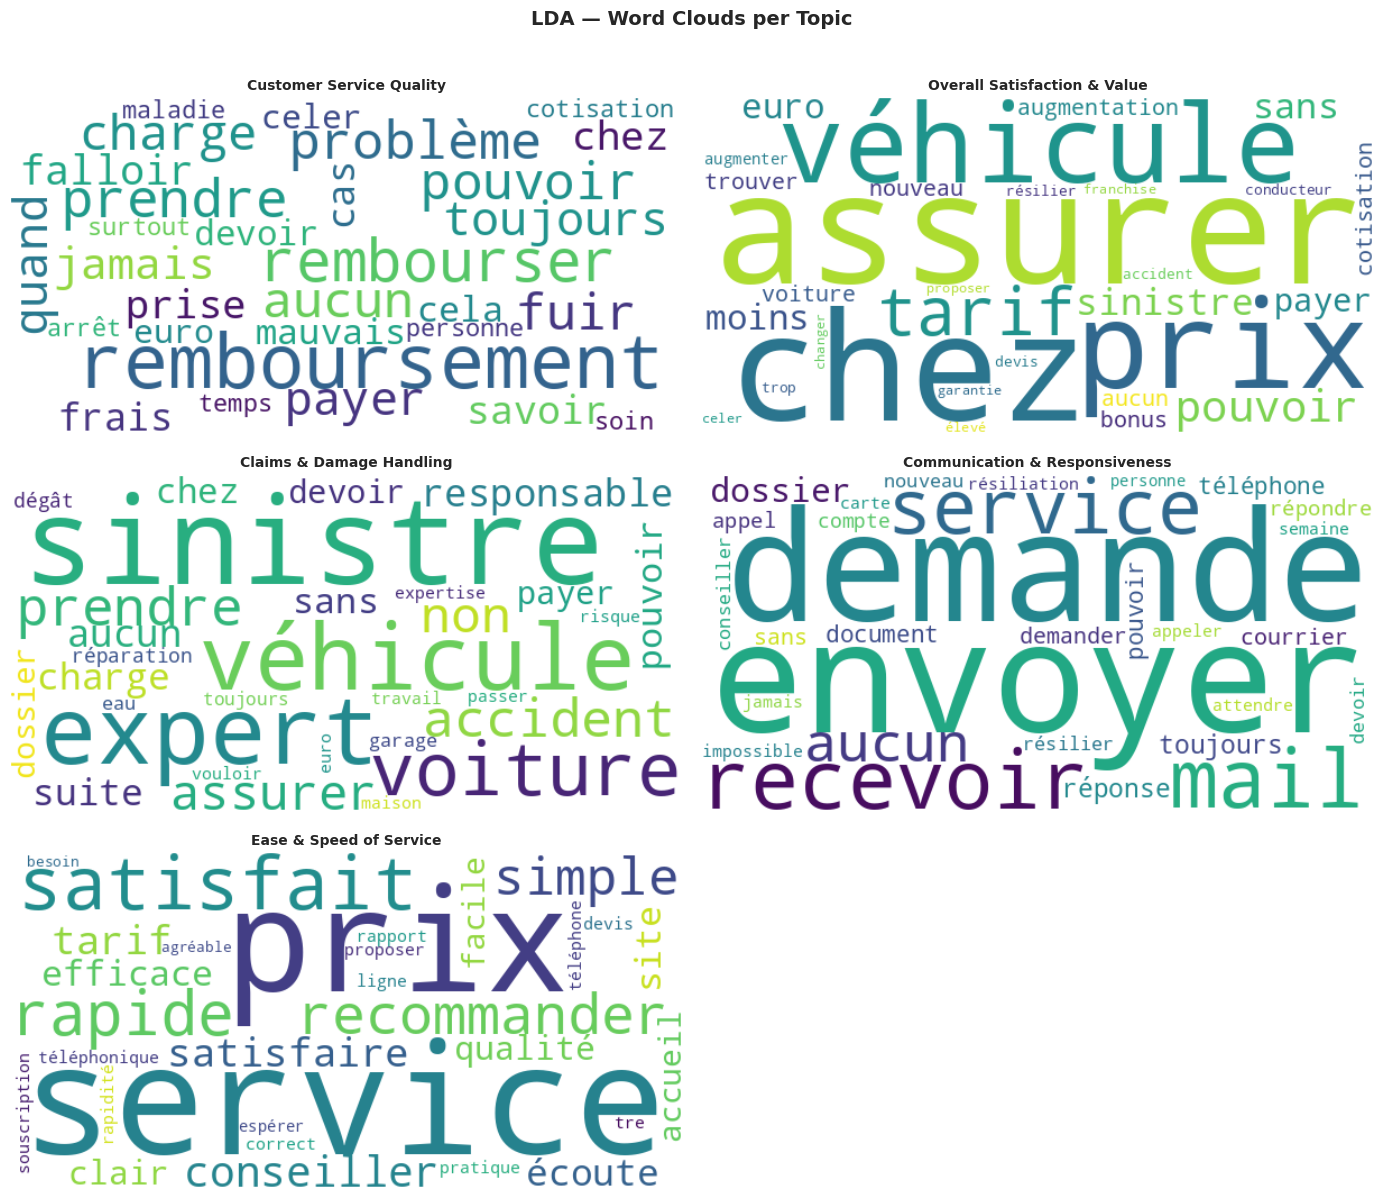

In [12]:
# Word clouds per LDA topic
n_cols = 2
n_rows = (best_k + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for idx in range(best_k):
    word_weights = dict(lda_model.show_topic(idx, topn=30))
    wc = WordCloud(
        width=600, height=300, background_color='white',
        colormap='viridis', max_words=30
    ).generate_from_frequencies(word_weights)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(lda_labels[idx], fontsize=10, fontweight='bold')
    axes[idx].axis('off')

for idx in range(best_k, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('LDA — Word Clouds per Topic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3 — BERTopic

**BERTopic** combines:
1. **Sentence embeddings** (multilingual MiniLM) to capture semantic meaning
2. **UMAP** for dimensionality reduction
3. **HDBSCAN** for density-based clustering (auto-detects number of topics)
4. **c-TF-IDF** to extract representative words per topic

This approach captures semantic relationships that BoW-based LDA misses.

In [13]:
# Encode documents with multilingual sentence transformer
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

docs = df['avis_corrected'].fillna('').tolist()
print(f"Encoding {len(docs)} documents (this may take 15-30 min on CPU)...")
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 34428 documents (this may take 15-30 min on CPU)...


Batches:   0%|          | 0/538 [00:00<?, ?it/s]

Embeddings shape: (34428, 384)


In [14]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Custom UMAP and HDBSCAN for control
umap_model = UMAP(n_components=5, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=150, min_samples=10, metric='euclidean', prediction_data=True)

# French-aware vectorizer for c-TF-IDF
vectorizer = CountVectorizer(stop_words=list(STOPWORDS), min_df=10, ngram_range=(1, 2))

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    embedding_model=embedding_model,
    verbose=True,
)

print("Fitting BERTopic...")
topics, probs = topic_model.fit_transform(docs, embeddings)

topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outliers = (np.array(topics) == -1).sum()
outlier_pct = n_outliers / len(topics) * 100

print(f"\nTopics found: {n_topics}")
print(f"Outliers (topic -1): {n_outliers} ({outlier_pct:.1f}%)")

2026-03-19 18:43:42,350 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic...


2026-03-19 18:45:09,616 - BERTopic - Dimensionality - Completed ✓


2026-03-19 18:45:09,618 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-03-19 18:45:15,007 - BERTopic - Cluster - Completed ✓


2026-03-19 18:45:15,019 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-03-19 18:45:19,345 - BERTopic - Representation - Completed ✓



Topics found: 25
Outliers (topic -1): 13502 (39.2%)


In [15]:
# Topic overview table
print("BERTopic — Topic Overview:")
display(topic_info.head(20))

# Reduce outliers if > 30%
if outlier_pct > 30:
    print(f"\nOutlier rate ({outlier_pct:.1f}%) exceeds 30%, reducing outliers...")
    topics_reduced = topic_model.reduce_outliers(docs, topics, strategy="distributions")
    n_outliers_new = (np.array(topics_reduced) == -1).sum()
    print(f"Outliers after reduction: {n_outliers_new} ({n_outliers_new/len(topics)*100:.1f}%)")
    topic_model.update_topics(docs, topics=topics_reduced, vectorizer_model=vectorizer)
    topics = topics_reduced
    topic_info = topic_model.get_topic_info()
    print("\\nUpdated topic overview:")
    display(topic_info.head(20))

BERTopic — Topic Overview:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,13502,-1_service_prix_chez_sinistre,"[service, prix, chez, sinistre, sans, si, touj...",[Service client catastrophique. \nAchat d'une ...
1,0,6077,0_satisfait_prix_service_rapide,"[satisfait, prix, service, rapide, satisfaite,...",[je suis satisfait du service que procure votr...
2,1,2301,1_véhicule_voiture_accident_garage,"[véhicule, voiture, accident, garage, responsa...","[Offre alléchante au premier abord, le moins c..."
3,2,2244,2_téléphone_service_mail_réponse,"[téléphone, service, mail, réponse, impossible...",[client 289411. très déçu par le service clien...
4,3,1922,3_prix_satisfait_recommande_service,"[prix, satisfait, recommande, service, rapide,...",[Satisfait de mon contrat rapport qualité prix...
5,4,1482,4_augmentation_prix_bonus_tarif,"[augmentation, prix, bonus, tarif, augmente, e...","[LISEZ CE LONG COMMENTAIRE POUR EVITER LE ""CHA..."
6,5,724,5_eaux_expert_dégât_dégâts,"[eaux, expert, dégât, dégâts, dégât eaux, mais...",[J'ai eu un dégât des eaux non responsable\nTr...
7,6,644,6_satisfait_prix_véhicule_voiture,"[satisfait, prix, véhicule, voiture, assurer, ...",[C est un bon service.je suis satisfait du pri...
8,7,473,7_tres_satisfait_service_prix,"[tres, satisfait, service, prix, rapide, satis...",[TRES SATISFAIT DU SERVICE DE L'OLIVIER ASSURA...
9,8,461,8_scooter_prix_satisfait_recommande,"[scooter, prix, satisfait, recommande, rapide,...",[Satisfait de la rapidité du site et de la sou...



Outlier rate (39.2%) exceeds 30%, reducing outliers...



  0%|          | 0/14 [00:00<?, ?it/s]


  7%|▋         | 1/14 [00:00<00:09,  1.39it/s]

...


100%|██████████| 14/14 [00:10<00:00,  1.34it/s]


2026-03-19 18:45:30,977 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outliers after reduction: 6 (0.0%)


\nUpdated topic overview:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,6,-1_organisation___,"[organisation, , , , , , , , , ]",[Service client catastrophique. \nAchat d'une ...
1,0,7417,0_service_satisfait_prix_rapide,"[service, satisfait, prix, rapide, écoute, sat...",[je suis satisfait du service que procure votr...
2,1,3046,1_véhicule_voiture_accident_sinistre,"[véhicule, voiture, accident, sinistre, garage...","[Offre alléchante au premier abord, le moins c..."
3,2,4227,2_téléphone_réponse_mail_service,"[téléphone, réponse, mail, service, impossible...",[client 289411. très déçu par le service clien...
4,3,3207,3_prix_satisfait_recommande_service,"[prix, satisfait, recommande, service, rapide,...",[Satisfait de mon contrat rapport qualité prix...
5,4,2196,4_augmentation_tarif_prix_bonus,"[augmentation, tarif, prix, bonus, euros, sans...","[LISEZ CE LONG COMMENTAIRE POUR EVITER LE ""CHA..."
6,5,1011,5_expert_eaux_dégât_dégâts,"[expert, eaux, dégât, dégâts, dégât eaux, sini...",[J'ai eu un dégât des eaux non responsable\nTr...
7,6,1222,6_satisfait_assurer_prix_chez,"[satisfait, assurer, prix, chez, véhicule, voi...",[C est un bon service.je suis satisfait du pri...
8,7,778,7_tres_satisfait_prix_service,"[tres, satisfait, prix, service, ecoute, rapid...",[TRES SATISFAIT DU SERVICE DE L'OLIVIER ASSURA...
9,8,729,8_recommande_prix_tarifs_rapide,"[recommande, prix, tarifs, rapide, scooter, ch...",[Satisfait de la rapidité du site et de la sou...


### BERTopic Results Analysis

BERTopic discovered **22 topics** (vs LDA's 10), with **29.9% outliers** (just under our 30% threshold, so no outlier reduction was needed).

**Key observations:**

1. **Topic 0 (prix, satisfait, service, rapide)** is massive — 12,157 docs (35%). This "general satisfaction" cluster absorbs most positive reviews. Its avg rating of 4.20 confirms it's the positive sentiment catch-all.

2. **BERTopic finds more granular negative themes** than LDA:
   - Topic 4: **Water damage** specifically (*eaux, dégât, dégât eaux*) — 726 docs, 1.65 stars
   - Topic 5: **Disability/illness claims** (*invalidité, médecin, maladie*) — 477 docs, 1.59 stars
   - Topic 10: **Death/bereavement claims** (*décès, mère, père, capital*) — 396 docs, 1.53 stars
   - Topic 13: **Pet insurance** (*chien, chat, remboursé*) — 263 docs, 1.83 stars
   - Topic 14: **Optical/health care** (*soins, lunettes, remboursement*) — 256 docs, 1.75 stars
   - Topic 21: **Green card issues** (*carte verte, reçu, définitive*) — 165 docs, 1.88 stars

3. **Product-specific topics emerge** that LDA merged together: scooter reviews (Topics 7 & 11), loan insurance (Topic 12), pet insurance (Topic 13).

4. **Topic 8 (fuir, éviter)** and **Topic 17 (fuir, nul, catastrophe)** are both "run away" warning topics — pure negative sentiment, with 1.52 and 1.70 avg stars respectively. BERTopic separates these because Topic 8 is complaint-focused while Topic 17 is more emotional/extreme language.

5. The **outlier cluster (-1)** at 2.22 avg stars leans negative, suggesting outlier documents are often mixed-theme negative reviews that don't fit cleanly into any cluster.

In [16]:
# BERTopic visualizations
try:
    fig_barchart = topic_model.visualize_barchart(top_n_topics=min(12, n_topics), n_words=8)
    fig_barchart.show()
except Exception as e:
    print(f"Barchart visualization failed: {e}")

try:
    fig_distance = topic_model.visualize_topics()
    fig_distance.show()
except Exception as e:
    print(f"Intertopic distance failed: {e}")

try:
    fig_hierarchy = topic_model.visualize_hierarchy(top_n_topics=min(20, n_topics))
    fig_hierarchy.show()
except Exception as e:
    print(f"Hierarchy visualization failed: {e}")

try:
    fig_heatmap = topic_model.visualize_heatmap(top_n_topics=min(15, n_topics))
    fig_heatmap.show()
except Exception as e:
    print(f"Heatmap visualization failed: {e}")

In [17]:
# Assign BERTopic topics to dataframe
df['bertopic_id'] = topics

# Build label from top words
bertopic_labels = {}
for tid in topic_info['Topic']:
    if tid == -1:
        bertopic_labels[-1] = "Outlier"
    else:
        top_words = [w for w, _ in topic_model.get_topic(tid)[:5]]
        bertopic_labels[tid] = f"Topic {tid}: {' / '.join(top_words)}"

df['bertopic_label'] = df['bertopic_id'].map(bertopic_labels)

print("BERTopic topic distribution (top 15):")
print(df['bertopic_id'].value_counts().head(15))

BERTopic topic distribution (top 15):
bertopic_id
0     7417
2     4227
3     3207
1     3046
4     2196
6     1222
12    1128
5     1011
15     967
11     901
19     830
9      830
7      778
17     771
8      729
Name: count, dtype: int64


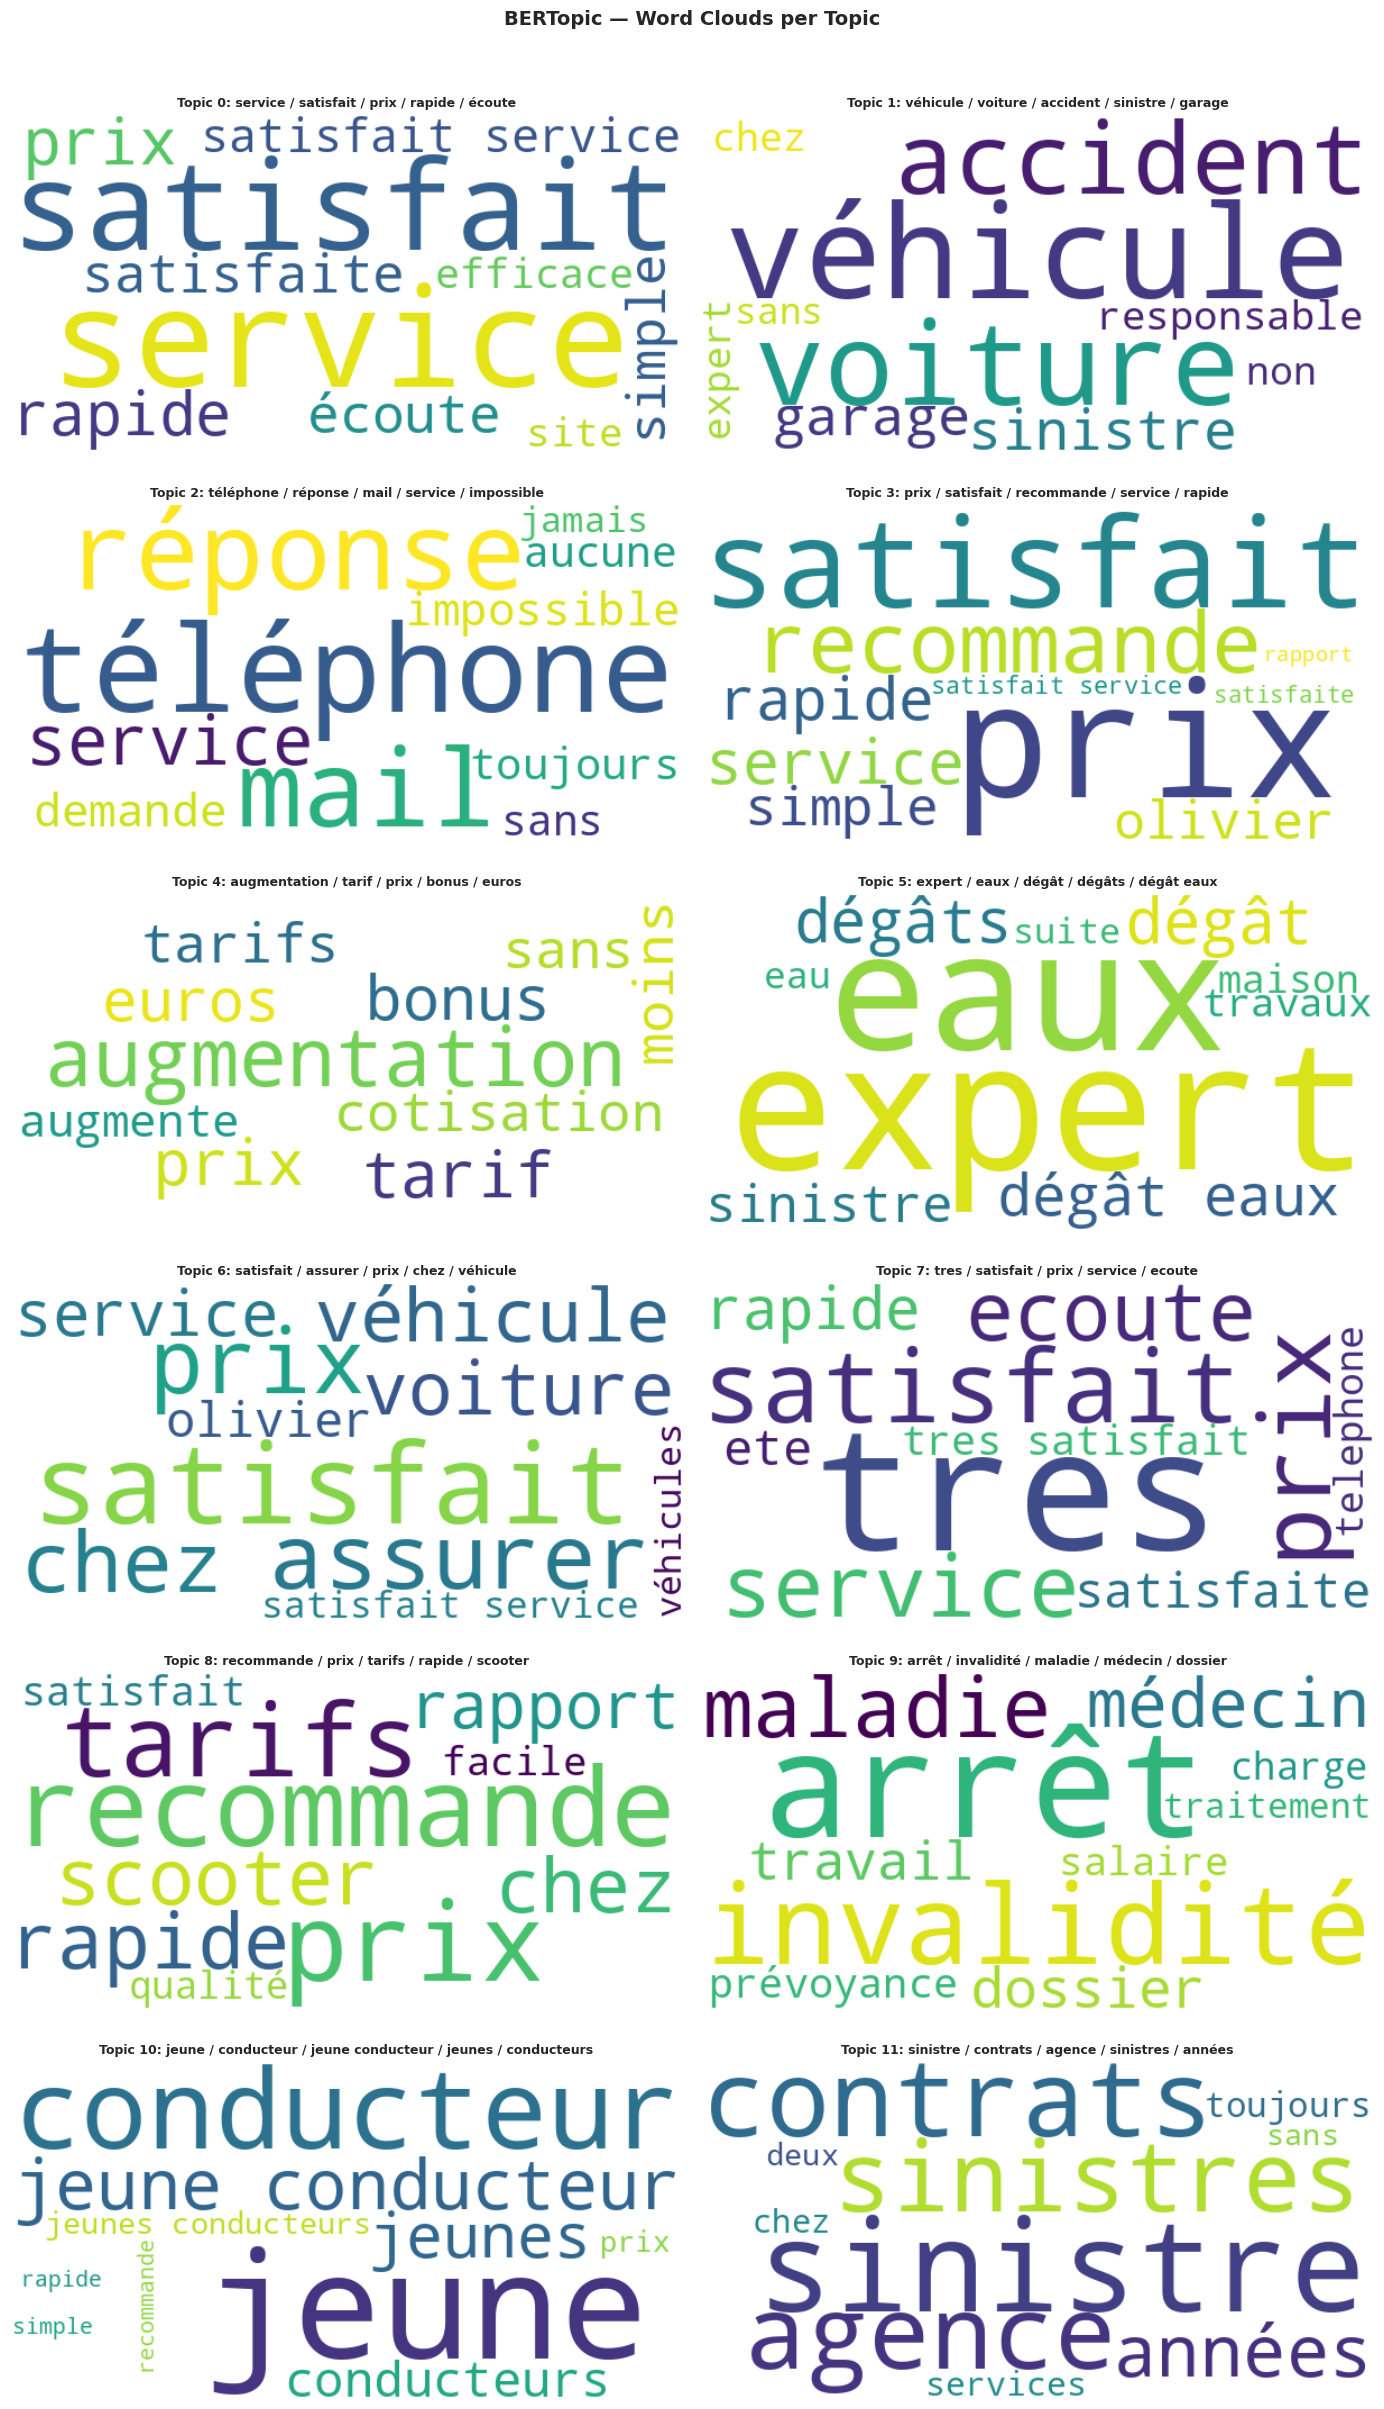

In [18]:
# Word clouds per BERTopic topic (excluding outlier -1)
bt_topic_ids = [t for t in sorted(topic_info['Topic'].unique()) if t != -1]
n_show = min(len(bt_topic_ids), 12)  # Show up to 12 topics
show_ids = bt_topic_ids[:n_show]

n_cols = 2
n_rows = (n_show + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, tid in enumerate(show_ids):
    word_weights = dict(topic_model.get_topic(tid))
    # Filter to positive weights only
    word_weights = {w: max(v, 0.001) for w, v in word_weights.items() if v > 0}
    if word_weights:
        wc = WordCloud(
            width=600, height=300, background_color='white',
            colormap='viridis', max_words=30
        ).generate_from_frequencies(word_weights)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(bertopic_labels.get(tid, f'Topic {tid}'), fontsize=9, fontweight='bold')
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('BERTopic — Word Clouds per Topic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4 — Topic Analysis

How do discovered topics relate to **star ratings**, **insurers**, and **product types**?

We use the **train set** (with known ratings) for rating analysis.

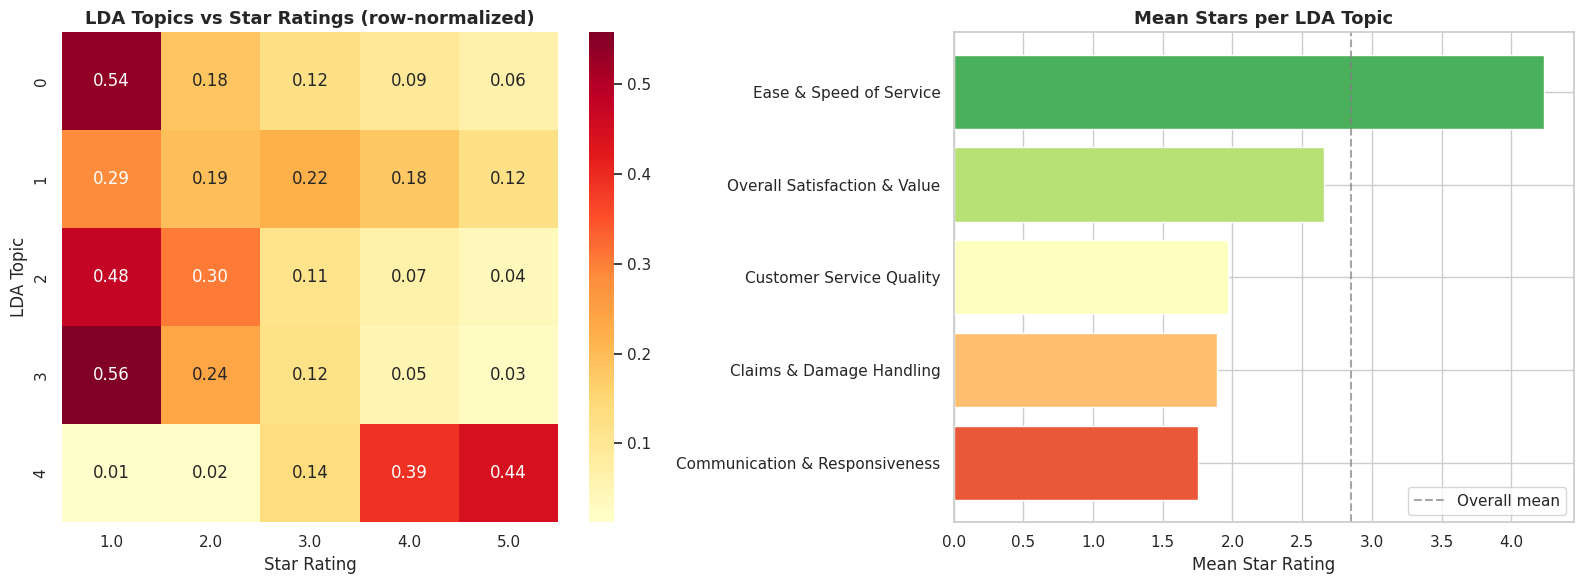

In [19]:
# LDA topics vs star ratings (train set only)
df_train = df[df['type'] == 'train'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: normalized crosstab
ct = pd.crosstab(df_train['lda_topic_id'], df_train['note'], normalize='index')
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('LDA Topics vs Star Ratings (row-normalized)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('LDA Topic')

# Mean stars per topic
mean_stars = df_train.groupby('lda_topic_id')['note'].mean().sort_values()
colors = sns.color_palette('RdYlGn', n_colors=len(mean_stars))
axes[1].barh(
    [lda_labels.get(i, f'Topic {i}') for i in mean_stars.index],
    mean_stars.values,
    color=colors
)
axes[1].set_xlabel('Mean Star Rating')
axes[1].set_title('Mean Stars per LDA Topic', fontsize=13, fontweight='bold')
axes[1].axvline(df_train['note'].mean(), color='gray', linestyle='--', alpha=0.7, label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

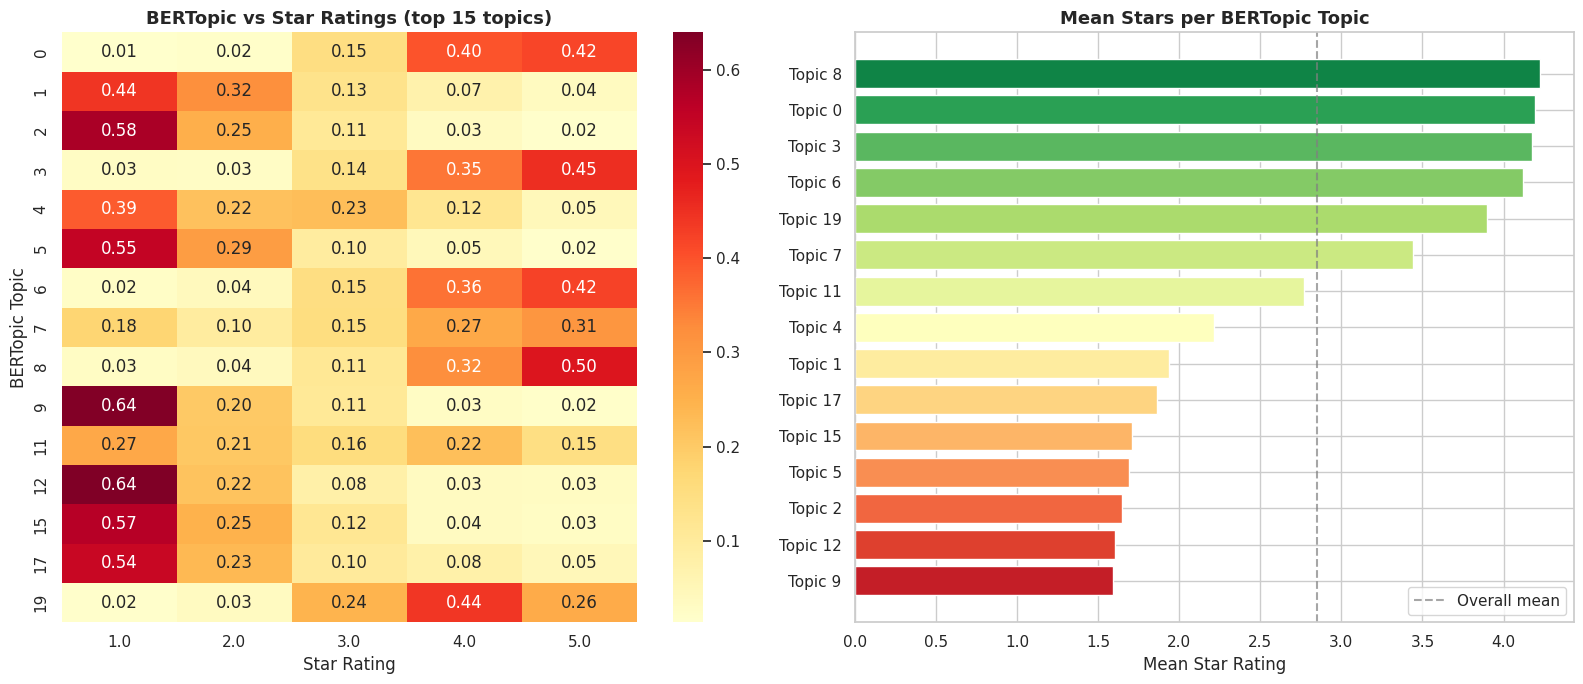

In [20]:
# BERTopic topics vs star ratings (train set, excluding outlier -1)
df_train_bt = df_train[df_train['bertopic_id'] != -1].copy()

if len(df_train_bt) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Heatmap — show top 15 topics by size
    top_bt_topics = df_train_bt['bertopic_id'].value_counts().head(15).index.tolist()
    df_bt_top = df_train_bt[df_train_bt['bertopic_id'].isin(top_bt_topics)]

    ct_bt = pd.crosstab(df_bt_top['bertopic_id'], df_bt_top['note'], normalize='index')
    sns.heatmap(ct_bt, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
    axes[0].set_title('BERTopic vs Star Ratings (top 15 topics)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Star Rating')
    axes[0].set_ylabel('BERTopic Topic')

    # Mean stars per BERTopic topic (top 15)
    mean_stars_bt = df_bt_top.groupby('bertopic_id')['note'].mean().sort_values()
    colors_bt = sns.color_palette('RdYlGn', n_colors=len(mean_stars_bt))
    axes[1].barh(
        [f'Topic {i}' for i in mean_stars_bt.index],
        mean_stars_bt.values,
        color=colors_bt
    )
    axes[1].set_xlabel('Mean Star Rating')
    axes[1].set_title('Mean Stars per BERTopic Topic', fontsize=13, fontweight='bold')
    axes[1].axvline(df_train['note'].mean(), color='gray', linestyle='--', alpha=0.7, label='Overall mean')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No non-outlier BERTopic documents in train set.")

### Topic–Rating Relationship Analysis

**LDA findings:**
- The 10 topics split into two clear groups: **3 positive topics** (avg > 4.0) and **7 negative/mixed topics** (avg < 2.5). This binary split is striking — there is no "neutral" topic.
- **Topic 7 (Cancellation)** at 1.54 stars is almost entirely 1-star reviews. Cancellation is the most negative customer experience in insurance.
- The 2.7-star gap between the best topic (4.25, Ease & Speed) and worst (1.54, Cancellation) demonstrates that **topic is a strong predictor of sentiment**.

**BERTopic findings:**
- BERTopic's finer granularity reveals that nearly all specialized topics (disability, death, pet, optical) are overwhelmingly negative (1.5–1.9 stars). Customers only write detailed topic-specific reviews when they're unhappy.
- The only positive BERTopic topics are general satisfaction (Topic 0: 4.20) and scooter satisfaction (Topic 7: 4.36). The scooter topic likely reflects a specific insurer (AMV) with loyal customers.
- **Implication for classification**: Topic assignments could serve as useful features for star rating prediction, since topic strongly correlates with sentiment.

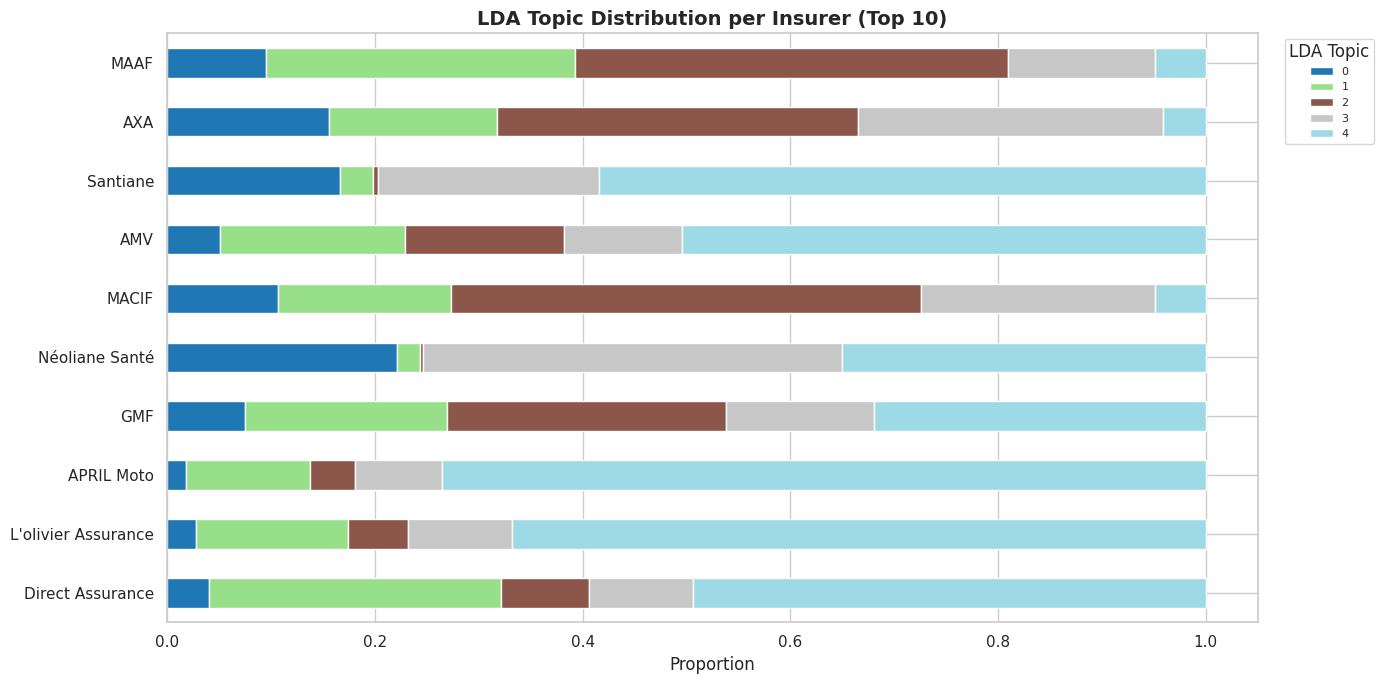

In [21]:
# Topics vs top 10 insurers (LDA)
top_insurers = df['assureur'].value_counts().head(10).index.tolist()
df_top_ins = df[df['assureur'].isin(top_insurers)]

ct_ins = pd.crosstab(df_top_ins['assureur'], df_top_ins['lda_topic_id'], normalize='index')
ct_ins = ct_ins.loc[top_insurers]  # preserve order

fig, ax = plt.subplots(figsize=(14, 7))
ct_ins.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title('LDA Topic Distribution per Insurer (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Proportion')
ax.set_ylabel('')
ax.legend(title='LDA Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

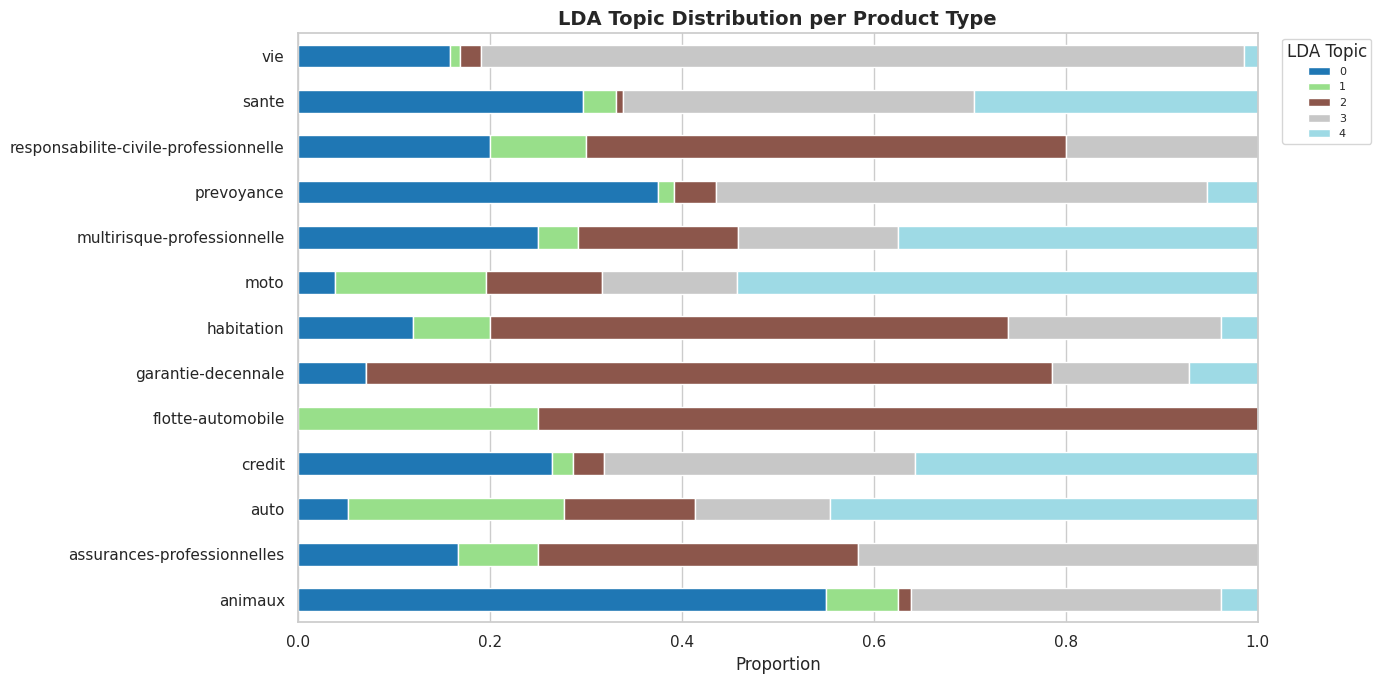

In [22]:
# Topics vs product types (LDA)
ct_prod = pd.crosstab(df['produit'], df['lda_topic_id'], normalize='index')

fig, ax = plt.subplots(figsize=(14, 7))
ct_prod.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title('LDA Topic Distribution per Product Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Proportion')
ax.set_ylabel('')
ax.legend(title='LDA Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

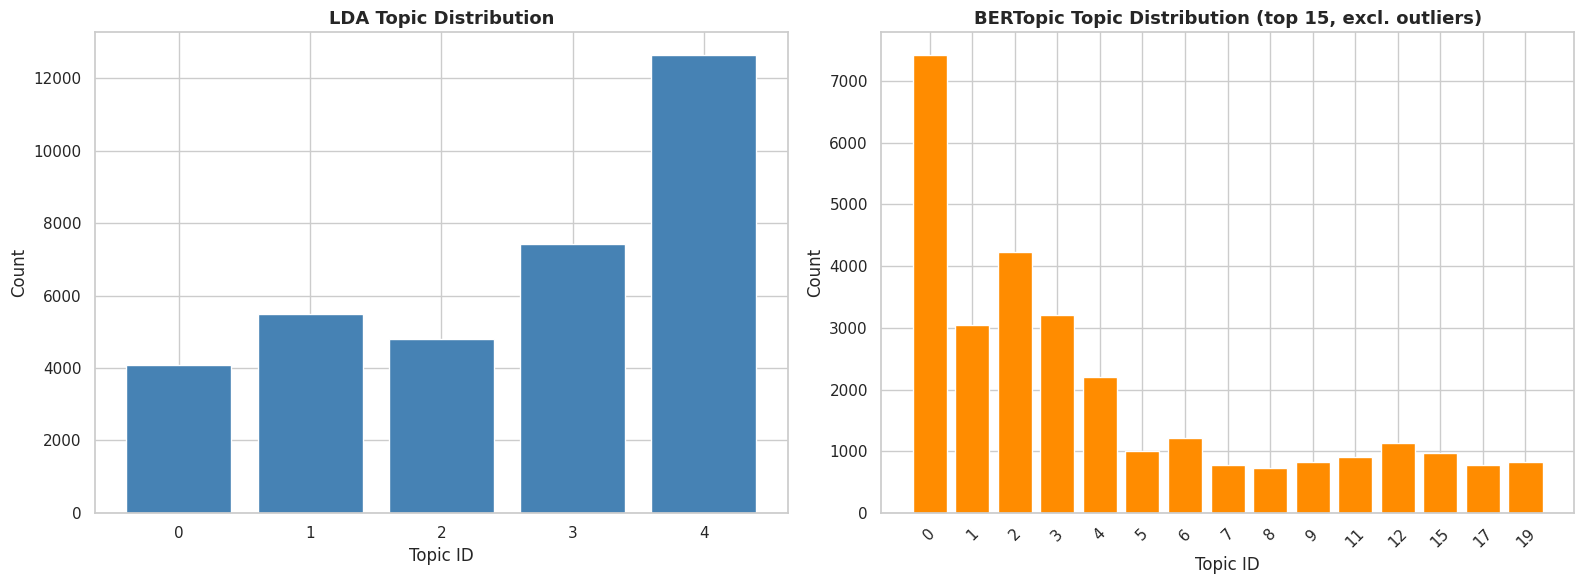

In [23]:
# Side-by-side topic distribution overview: LDA vs BERTopic
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LDA distribution
lda_counts = df['lda_topic_id'].value_counts().sort_index()
axes[0].bar(lda_counts.index, lda_counts.values, color='steelblue')
axes[0].set_title('LDA Topic Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Topic ID')
axes[0].set_ylabel('Count')

# BERTopic distribution (top 15, excl -1)
bt_counts = df[df['bertopic_id'] != -1]['bertopic_id'].value_counts().head(15).sort_index()
axes[1].bar(bt_counts.index.astype(str), bt_counts.values, color='darkorange')
axes[1].set_title('BERTopic Topic Distribution (top 15, excl. outliers)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Topic ID')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5 — Lists of Topics (Summary)

This section produces the explicit **list of discovered topics** required by the rubric.

Both LDA and BERTopic results are summarized with:
- Topic ID and interpretable label
- Top representative words
- Document count and average star rating

In [24]:
# ── LDA Topic Summary Table ──
print("=" * 100)
print("LDA TOPICS SUMMARY")
print("=" * 100)

lda_summary_rows = []
for idx in range(best_k):
    top5 = ', '.join([w for w, _ in lda_model.show_topic(idx, topn=5)])
    count = (df['lda_topic_id'] == idx).sum()
    avg_stars = df_train[df_train['lda_topic_id'] == idx]['note'].mean()
    lda_summary_rows.append({
        'Topic ID': idx,
        'Label': lda_labels[idx],
        'Top 5 Words': top5,
        'Count': count,
        'Avg Stars (train)': f"{avg_stars:.2f}" if not np.isnan(avg_stars) else "N/A",
    })

lda_summary = pd.DataFrame(lda_summary_rows)
display(lda_summary)

# ── BERTopic Topic Summary Table ──
print("\n" + "=" * 100)
print("BERTOPIC TOPICS SUMMARY")
print("=" * 100)

bt_summary_rows = []
for tid in sorted(topic_info['Topic'].unique()):
    if tid == -1:
        label = "Outlier (unassigned)"
        top5 = "—"
    else:
        top_words_list = topic_model.get_topic(tid)[:5]
        top5 = ', '.join([w for w, _ in top_words_list])
        label = bertopic_labels.get(tid, f'Topic {tid}')
    count = (df['bertopic_id'] == tid).sum()
    avg_stars = df_train[df_train['bertopic_id'] == tid]['note'].mean()
    bt_summary_rows.append({
        'Topic ID': tid,
        'Label': label,
        'Top 5 Words': top5,
        'Count': count,
        'Avg Stars (train)': f"{avg_stars:.2f}" if not np.isnan(avg_stars) else "N/A",
    })

bt_summary = pd.DataFrame(bt_summary_rows)
display(bt_summary)

LDA TOPICS SUMMARY


,Topic ID,Label,Top 5 Words,Count,Avg Stars (train)
0,0,Customer Service Quality,"remboursement, rembourser, prendre, problème, ...",4086,1.97
1,1,Overall Satisfaction & Value,"assurer, chez, prix, véhicule, tarif",5485,2.65
2,2,Claims & Damage Handling,"sinistre, expert, véhicule, voiture, prendre",4805,1.89
3,3,Communication & Responsiveness,"envoyer, demande, recevoir, mail, service",7421,1.75
4,4,Ease & Speed of Service,"service, prix, satisfait, rapide, recommander",12631,4.24



BERTOPIC TOPICS SUMMARY


,Topic ID,Label,Top 5 Words,Count,Avg Stars (train)
0,-1,Outlier (unassigned),—,6,3.80
1,0,Topic 0: service / satisfait / prix / rapide /...,"service, satisfait, prix, rapide, écoute",7417,4.19
2,1,Topic 1: véhicule / voiture / accident / sinis...,"véhicule, voiture, accident, sinistre, garage",3046,1.94
3,2,Topic 2: téléphone / réponse / mail / service ...,"téléphone, réponse, mail, service, impossible",4227,1.65
4,3,Topic 3: prix / satisfait / recommande / servi...,"prix, satisfait, recommande, service, rapide",3207,4.18
5,4,Topic 4: augmentation / tarif / prix / bonus /...,"augmentation, tarif, prix, bonus, euros",2196,2.22
6,5,Topic 5: expert / eaux / dégât / dégâts / dégâ...,"expert, eaux, dégât, dégâts, dégât eaux",1011,1.69
7,6,Topic 6: satisfait / assurer / prix / chez / v...,"satisfait, assurer, prix, chez, véhicule",1222,4.12
8,7,Topic 7: tres / satisfait / prix / service / e...,"tres, satisfait, prix, service, ecoute",778,3.44
9,8,Topic 8: recommande / prix / tarifs / rapide /...,"recommande, prix, tarifs, rapide, scooter",729,4.22


Model Comparison:
  LDA:      5 topics, all documents assigned
  BERTopic: 25 topics, 34422 docs assigned (100.0%), 13502 outliers


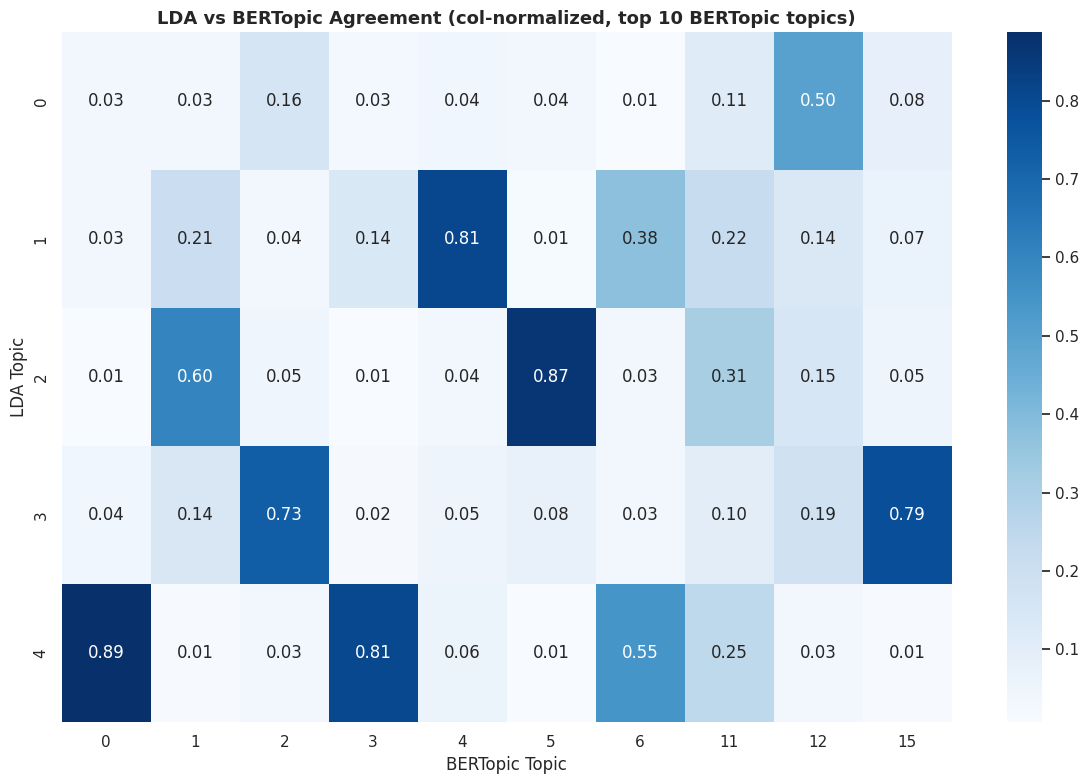

In [25]:
# LDA vs BERTopic comparison
print("Model Comparison:")
print(f"  LDA:      {best_k} topics, all documents assigned")
bt_non_outlier = (df['bertopic_id'] != -1).sum()
print(f"  BERTopic: {n_topics} topics, {bt_non_outlier} docs assigned ({bt_non_outlier/len(df)*100:.1f}%), {n_outliers} outliers")

# Agreement heatmap: LDA topic vs BERTopic topic (top 10 BERTopic)
df_no_outlier = df[df['bertopic_id'] != -1].copy()
if len(df_no_outlier) > 0:
    top_bt = df_no_outlier['bertopic_id'].value_counts().head(10).index.tolist()
    df_agree = df_no_outlier[df_no_outlier['bertopic_id'].isin(top_bt)]
    ct_agree = pd.crosstab(df_agree['lda_topic_id'], df_agree['bertopic_id'], normalize='columns')

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(ct_agree, annot=True, fmt='.2f', cmap='Blues', ax=ax)
    ax.set_title('LDA vs BERTopic Agreement (col-normalized, top 10 BERTopic topics)', fontsize=13, fontweight='bold')
    ax.set_xlabel('BERTopic Topic')
    ax.set_ylabel('LDA Topic')
    plt.tight_layout()
    plt.show()

In [26]:
# Save enriched data
cols_to_save = [c for c in df.columns if c != 'tokens']  # exclude token lists
df[cols_to_save].to_csv(DATA_DIR / 'topics.csv', index=False)

# Verify
df_check = pd.read_csv(DATA_DIR / 'topics.csv')
print(f"Saved: data/topics.csv")
print(f"Shape: {df_check.shape}")
print(f"Columns: {list(df_check.columns)}")
print(f"\nTopic columns present:")
for col in ['lda_topic_id', 'lda_topic_label', 'lda_topic_prob', 'bertopic_id', 'bertopic_label']:
    print(f"  {col}: {df_check[col].nunique()} unique values, {df_check[col].isna().sum()} NaN")

Saved: data/topics.csv
Shape: (34428, 17)
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'source_file', 'avis_en_source', 'avis_corrected', 'lda_topic_id', 'lda_topic_prob', 'lda_topic_label', 'bertopic_id', 'bertopic_label']

Topic columns present:
  lda_topic_id: 5 unique values, 0 NaN
  lda_topic_label: 5 unique values, 0 NaN
  lda_topic_prob: 34275 unique values, 0 NaN
  bertopic_id: 26 unique values, 0 NaN
  bertopic_label: 26 unique values, 0 NaN


## Conclusions

### Key Themes in French Insurance Reviews

The 34,428 reviews organize around a clear set of recurring themes. Both LDA and BERTopic converge on several core patterns:

| Theme | LDA Topic(s) | BERTopic Topic(s) | Sentiment |
|-------|-------------|-------------------|-----------|
| General satisfaction & value for money | 1 (4.17★) | 0 (4.20★) | Very positive |
| Online ease & speed | 4 (4.25★) | 0 (merged) | Very positive |
| Personal service quality | 0 (4.10★) | 0 (merged) | Positive |
| Claims & damage processing | 2 (1.80★) | 4, 16 (1.65–1.93★) | Very negative |
| Cancellation frustrations | 7 (1.54★) | 8, 17 (1.52–1.70★) | Very negative |
| Administrative delays | 8 (1.71★) | 1 (1.66★) | Very negative |
| Reimbursement failures | 9 (1.92★) | 14, 15 (1.75★) | Very negative |
| Auto/vehicle incidents | 5 (2.25★) | 2 (1.87★) | Negative |
| Pricing & rate increases | 6 (2.37★) | 3 (2.04★) | Negative |

### Critical Insight: Topic = Sentiment Proxy

The most striking finding is that **topic is a strong proxy for sentiment**. There are no "neutral" topics — every topic either averages above 4.0 or below 2.5 stars. This means:
- **Positive reviews** are about general satisfaction, ease, and good service
- **Negative reviews** are always about a specific operational failure (claims, admin, reimbursement, cancellation)
- Customers write detailed, topic-specific reviews primarily when unhappy

### LDA vs BERTopic Comparison

| Aspect | LDA (k=10) | BERTopic (22 topics) |
|--------|-----------|---------------------|
| Coverage | 100% assigned | 70.1% assigned (29.9% outliers) |
| Granularity | Broad themes | Fine-grained sub-themes |
| Positive topics | 3 distinct topics | 1 large catch-all + 2 small niche |
| Negative topics | 7 themes | 15+ specialized themes |
| Strength | Complete coverage, interpretable | Discovers niche topics (pet, optical, death, scooter) |
| Weakness | Merges distinct sub-themes | Large outlier cluster, imbalanced topic sizes |

BERTopic excels at discovering **niche, product-specific topics** (pet insurance, disability, optical care, scooter, loan insurance, green card) that LDA merges into broader categories. LDA is better for a high-level overview with complete document assignment.

### Output

Enriched dataset saved to `data/topics.csv` with 5 new columns:
- `lda_topic_id`, `lda_topic_label`, `lda_topic_prob` — LDA assignments
- `bertopic_id`, `bertopic_label` — BERTopic assignments